# ЦУР 3. Здоровье и благополучие в России

Зейда А.В., Капустник К.А. — ББИ-24-БА1

Дисциплина: «Анализ данных на Python».

Россия: 2015–2024. Территории: срезы 2015, 2019, 2021. Этот notebook заново готовит данные, выполняет проверки и строит иллюстрации отчёта. Официальные источники и версии находятся в `data/sources`, журнал сверки — в `data/quality`.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from prepare_data import build

rf, regions, tidy = build()
subjects = regions.loc[regions.type == "region"].copy()
print("Россия:", rf.shape, "Территории:", len(subjects))
display(rf)

Matplotlib is building the font cache; this may take a moment.


{
  "years": [
    2015,
    2024
  ],
  "territories": 85,
  "rows": 399,
  "missing_values": 6,
  "opzh_2024": 72.84,
  "opzh_2015_2019_change": 1.960000000000008,
  "target_gap_2024": 5.159999999999997,
  "infant_change_pct": -38.46153846153846,
  "regional_spread_2021": 12.280000000000001,
  "regional_correlation": -0.3755822110034976,
  "iqr_bounds_2021": [
    64.29500000000002,
    74.33499999999998
  ]
}
Россия: (10, 13) Территории: 85


col,year,births,cdr,deaths,inf_mort,mat_deaths,mat_mort,nat_inc,opzh,opzh_f,opzh_m,under5_mort,gender_gap
0,2015,1940579.0,13.0,1908541.0,6.5,196.0,10.1,32038.0,71.38,76.67,65.95,8.0,10.72
1,2016,1888729.0,12.8,1891015.0,6.0,188.0,10.0,-2286.0,71.87,77.01,66.54,7.4,10.47
2,2017,1690307.0,12.4,1826125.0,5.6,149.0,8.8,-135818.0,72.70,77.58,67.56,NaN,10.02
3,2018,1604344.0,12.4,1828910.0,5.1,146.0,9.1,-224566.0,72.91,77.74,67.82,6.3,9.92
4,2019,1481074.0,12.2,1798307.0,4.9,134.0,9.0,-317233.0,73.34,78.09,68.33,6.0,9.76
5,2020,1436514.0,14.5,2138586.0,4.5,161.0,11.2,-702072.0,71.58,76.38,66.65,5.5,9.73
6,2021,1398253.0,16.6,2441594.0,4.6,482.0,34.5,-1043341.0,70.15,74.50,65.69,5.8,8.81
7,2022,1304087.0,12.9,1898644.0,4.4,170.0,13.0,-594557.0,72.73,77.77,67.57,5.6,10.20
8,2023,1264354.0,12.1,1764618.0,4.2,168.0,13.3,-500264.0,73.41,78.74,68.04,5.3,10.70
9,2024,1222408.0,12.5,1818635.0,4.0,NaN,11.2,-596227.0,72.84,NaN,NaN,NaN,NaN


## 1. Подготовка и валидация

Исходные компиляции сохранены в `data/raw/original`. Основные входные CSV пересобраны из проверенных первичных выгрузок. Обработка чисел, ключи, территориальная модель и производные показатели находятся в `prepare_data.py`. Пропуски остаются NaN; для естественного прироста не рассчитываются индекс и относительный темп.

In [2]:
display(pd.read_csv("data/processed/validation.csv"))
display(tidy.loc[tidy.value.isna(), ["territory", "year", "code", "sex", "value"]])
assert not tidy.duplicated(["territory", "year", "code", "sex"]).any()
assert len(subjects) == 85
assert not subjects[["2015","2019","2021"]].isna().any().any()

,check,passed,detail
0,Родившиеся - умершие = естественный прирост,True,10 лет; максимальное расхождение 0 человек
1,Пересчёт материнской смертности,True,9 лет; максимальное расхождение 0.047 на 100 000
2,ОПЖ всего между мужским и женским значением,True,9 лет
3,Совпадение РФ в национальной и региональной та...,True,"2015, 2019, 2021"
4,Уникальные ключи итоговой таблицы,True,399 строк
5,Неперекрывающиеся территории сравнения,True,85 территорий; областные строки без АО явно по...
6,ОПЖ в проверочном диапазоне 55-90 лет,True,Выбросы по IQR сохранены; диапазон не доказыва...
7,Неотрицательные коэффициенты и числа событий,True,Естественный прирост может быть отрицательным


,territory,year,code,sex,value
398,Российская Федерация,2024,gender_gap,всего,NaN
104,Российская Федерация,2024,mat_deaths,всего,NaN
101,Российская Федерация,2024,opzh,женщины,NaN
100,Российская Федерация,2024,opzh,мужчины,NaN
32,Российская Федерация,2017,under5_mort,всего,NaN
109,Российская Федерация,2024,under5_mort,всего,NaN


In [3]:
FIG = Path("report/figures")
FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10, "axes.spines.top": False, "axes.spines.right": False, "axes.titleweight": "bold", "axes.grid": True, "grid.alpha": .22, "figure.facecolor": "white", "savefig.facecolor": "white"})
GREEN, BLUE, ORANGE = "#3b795c", "#457b9a", "#af633e"

def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / name, dpi=160, bbox_inches="tight")
    plt.show()

## 2. Продолжительность жизни

Национальная и региональная ОПЖ используют одну версию ЕМИСС 31293. Показатель отражает режим возрастной смертности соответствующего года; это не средний возраст умерших.

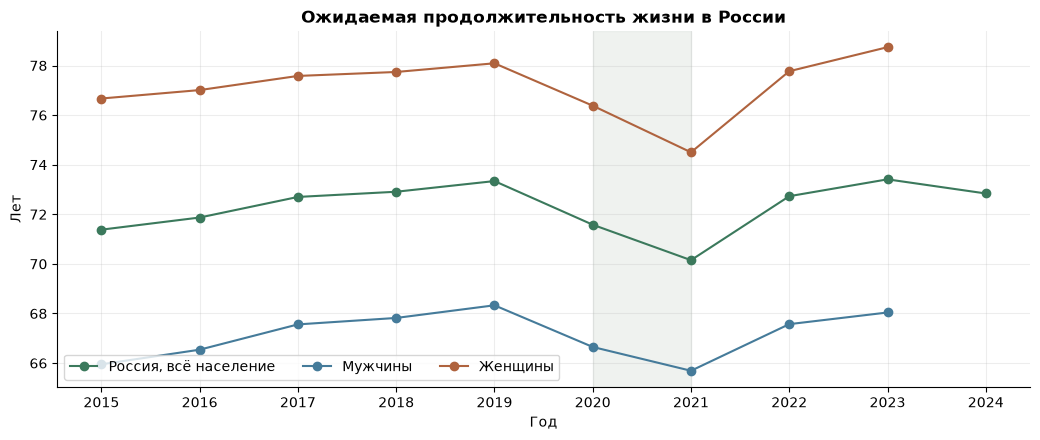

col,year,opzh,gender_gap
0,2015,71.38,10.72
1,2016,71.87,10.47
2,2017,72.70,10.02
3,2018,72.91,9.92
4,2019,73.34,9.76
5,2020,71.58,9.73
6,2021,70.15,8.81
7,2022,72.73,10.20
8,2023,73.41,10.70
9,2024,72.84,NaN


In [4]:
fig, ax = plt.subplots(figsize=(10.5, 4.5))
for column, label, color in [("opzh", "Россия, всё население", GREEN), ("opzh_m", "Мужчины", BLUE), ("opzh_f", "Женщины", ORANGE)]:
    ax.plot(rf.year, rf[column], marker="o", color=color, label=label)
ax.set(title="Ожидаемая продолжительность жизни в России", ylabel="Лет", xlabel="Год", xticks=rf.year)
ax.axvspan(2020, 2021, color="#dce4dd", alpha=.45)
ax.legend(loc="lower left", ncol=3)
save(fig, "opzh.png")
display(rf[["year", "opzh", "gender_gap"]])

## 3. Материнская и детская смертность

Материнская смертность — 3.1.1; смертность детей до пяти лет — 3.2.1. Младенческая смертность связана с задачей 3.2, но не равна неонатальной 3.2.2. Разные знаменатели показаны на отдельных панелях.

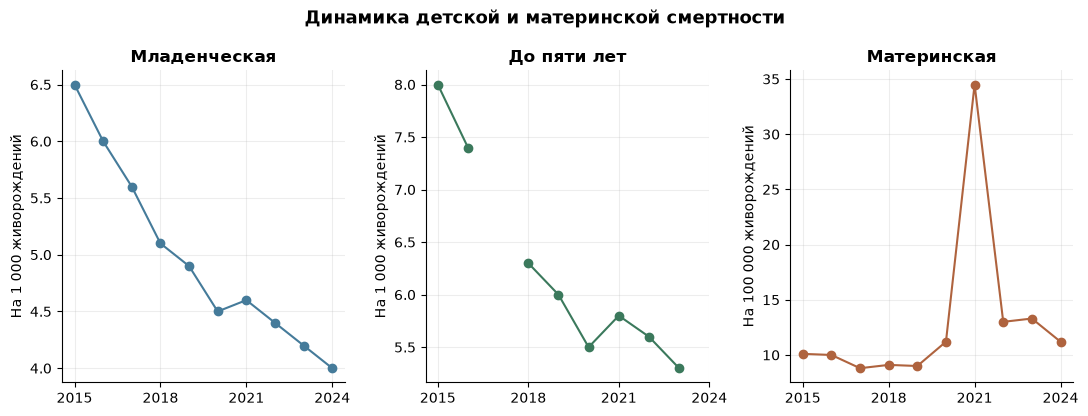

Снижение младенческой смертности, %: 38.46
Материнская смертность 2024: 11.2


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4.2))
for ax, col, title, unit, color in zip(axes, ["inf_mort", "under5_mort", "mat_mort"], ["Младенческая", "До пяти лет", "Материнская"], ["На 1 000 живорождений", "На 1 000 живорождений", "На 100 000 живорождений"], [BLUE, GREEN, ORANGE]):
    ax.plot(rf.year, rf[col], marker="o", color=color)
    ax.set(title=title, ylabel=unit, xticks=[2015,2018,2021,2024])
fig.suptitle("Динамика детской и материнской смертности", fontsize=13, fontweight="bold")
save(fig, "mortality.png")
print("Снижение младенческой смертности, %:", round((1-rf.iloc[-1].inf_mort/rf.iloc[0].inf_mort)*100,2))
print("Материнская смертность 2024:", rf.loc[rf.year==2024,"mat_mort"].iloc[0])

## 4. Естественное движение населения

Естественный прирост = родившиеся − умершие. Он не включает миграцию. Общий коэффициент смертности зависит также от возрастного состава населения.

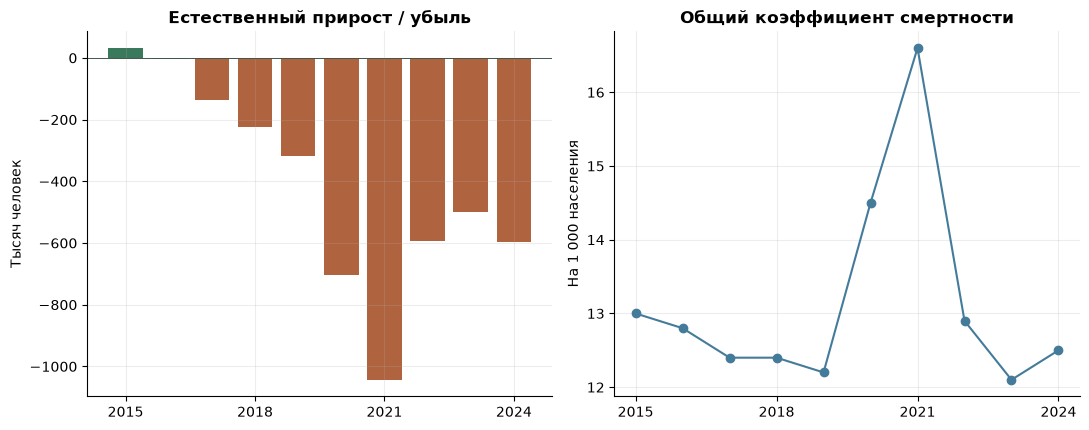

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].bar(rf.year, rf.nat_inc/1000, color=[GREEN if v>=0 else ORANGE for v in rf.nat_inc])
axes[0].axhline(0, color="#40564b", linewidth=.7)
axes[0].set(title="Естественный прирост / убыль", ylabel="Тысяч человек", xticks=[2015,2018,2021,2024])
axes[1].plot(rf.year, rf.cdr, color=BLUE, marker="o")
axes[1].set(title="Общий коэффициент смертности", ylabel="На 1 000 населения", xticks=[2015,2018,2021,2024])
save(fig,"natural.png")

## 5. Региональные различия

Для распределения используется 85 неперекрывающихся территорий. Области без автономных округов подписаны явно. Рейтинг учитывает равные значения. Значения страны и округов взяты из источника, а не из среднего по субъектам.

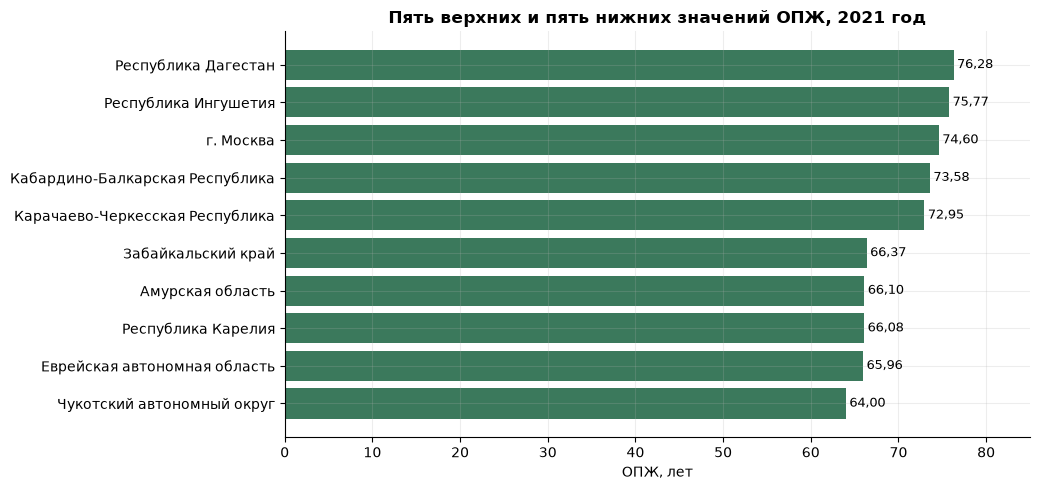

,territory,2021,rank_2021,deviation_2021
42,Республика Дагестан,76.28,1.0,6.13
43,Республика Ингушетия,75.77,2.0,5.62
19,г. Москва,74.60,3.0,4.45
44,Кабардино-Балкарская Республика,73.58,4.0,3.43
45,Карачаево-Черкесская Республика,72.95,5.0,2.80
31,г. Санкт-Петербург,72.89,6.0,2.74
47,Чеченская Республика,72.71,7.0,2.56
40,г. Севастополь,72.65,8.0,2.50
46,Республика Северная Осетия – Алания,72.30,9.0,2.15
68,Ханты-Мансийский автономный округ – Югра,72.16,10.0,2.01


Размах2021: 12.28
Корреляция исходного уровня с изменением: -0.3756


In [7]:
ordered = subjects.sort_values("2021", ascending=False)
view = pd.concat([ordered.head(5), ordered.tail(5)]).sort_values("2021")
fig, ax = plt.subplots(figsize=(10.5, 5))
ax.barh(view.territory, view["2021"], color=GREEN)
ax.set(xlabel="ОПЖ, лет", title="Пять верхних и пять нижних значений ОПЖ, 2021 год", xlim=(0,85))
for i,v in enumerate(view["2021"]):
    ax.text(v+.4,i,f"{v:.2f}".replace(".",","),va="center",fontsize=9)
save(fig,"regions.png")
display(ordered[["territory","2021","rank_2021","deviation_2021"]].head(10))
print("Размах2021:",round(subjects["2021"].max()-subjects["2021"].min(),2))
print("Корреляция исходного уровня с изменением:",round(subjects["2019"].corr(subjects.change_2019_2021),4))

Корреляция описательная. Изменение 2021 − 2019 уже содержит исходный уровень со знаком минус, поэтому математическая связанность не позволяет сделать причинный вывод. IQR-флаг — повод проверить наблюдение, а не основание его удалить.

In [8]:
display(subjects.loc[subjects.outlier_2021,["territory","2021"]])
display(subjects.group_2021.value_counts().rename("Число территорий"))

,territory,2021
19,г. Москва,74.60
42,Республика Дагестан,76.28
43,Республика Ингушетия,75.77
93,Чукотский автономный округ,64.00


group_2021
Ниже РФ на 1 год и более    45
Разница меньше 1 года       24
Выше РФ на 1 год и более    16
Name: Число территорий, dtype: int64

## 6. Приморский край

Сопоставляем значения Приморья, ДФО и РФ в одинаковые опорные годы.

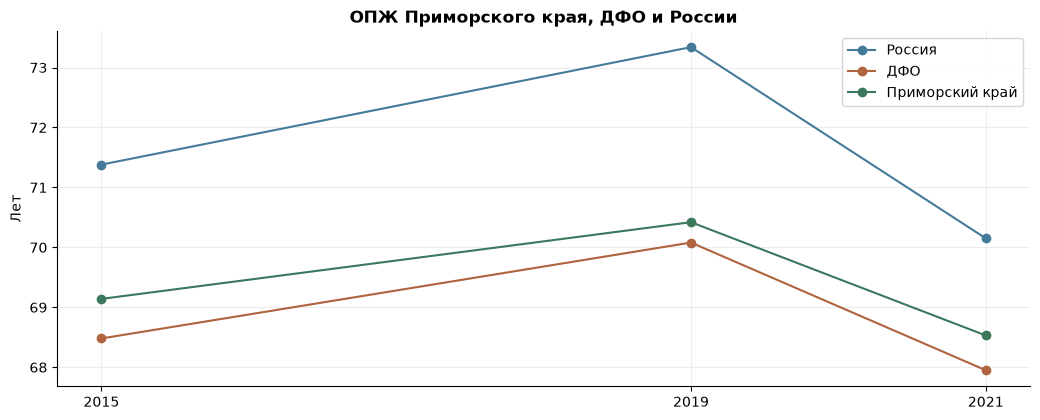

,territory,source_territory,type,district,2015,2019,2021,change_2015_2019,change_2019_2021,deviation_2021,rank_2021,outlier_2021,group_2021
87,Приморский край,Приморский край,region,ДФО,69.14,70.42,68.53,1.28,-1.89,-1.62,57.0,False,Ниже РФ на 1 год и более


In [9]:
fig, ax = plt.subplots(figsize=(10.5,4.3))
for territory,label,color in [("Российская Федерация","Россия",BLUE),("Дальневосточный федеральный округ","ДФО",ORANGE),("Приморский край","Приморский край",GREEN)]:
    row=regions.loc[regions.territory==territory].iloc[0]
    ax.plot([2015,2019,2021],[row[str(y)] for y in [2015,2019,2021]],label=label,marker="o",color=color)
ax.set(title="ОПЖ Приморского края, ДФО и России",ylabel="Лет",xticks=[2015,2019,2021])
ax.legend()
save(fig,"primorye.png")
display(subjects.loc[subjects.territory=="Приморский край"])

## 7. Условный ориентир 2030

Расчёт равномерного годового прироста до 78 лет является арифметическим сценарием, а не прогнозом.

In [10]:
last=rf.loc[rf.year==2024,"opzh"].iloc[0]
print(f"Разница до 78 лет: {78-last:.2f} года")
print(f"При равномерном росте2024–2030: {(78-last)/6:.2f} года в год")
print(f"Средний прирост2015–2019: {(rf.loc[rf.year==2019,"opzh"].iloc[0]-rf.loc[rf.year==2015,"opzh"].iloc[0])/4:.2f} года в год")

Разница до 78 лет: 5.16 года
При равномерном росте2024–2030: 0.86 года в год
Средний прирост2015–2019: 0.49 года в год


## 8. Интерактивная версия и выводы

Откройте `dashboard/index.html` или запустите `streamlit run app.py`. В дашборде доступны диапазон лет, показатели, округ, территории и связанные региональные графики. Отчёт содержит интерпретацию результатов и ограничения. Ссылка и правила доступа указаны в README.